# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
# Store the number of marketing campaigns in the dataset.
campaigns = 17
campaigns


17

**Observation:** The data covers 17 marketing campaigns. The data was collected over several years.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
# Import the libraries used in this notebook.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from time import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


In [3]:
# Load the bank marketing data.
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df['subscribed'] = df['y'].map({'no': 0, 'yes': 1})


In [4]:
# Display the first five rows of the data.
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [5]:
# Summarize the numeric columns.
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


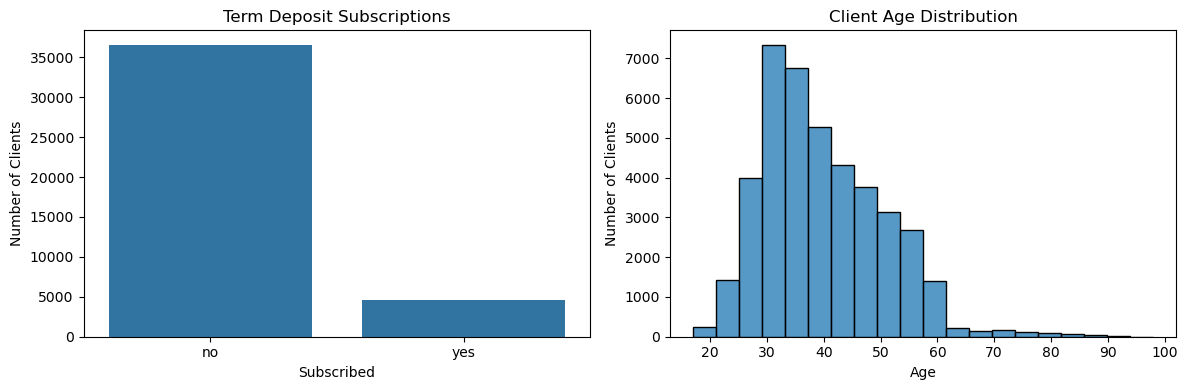

In [6]:
# Plot subscriptions and the age distribution.
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
sns.countplot(data = df, x = 'y', ax = ax[0])
ax[0].set_title('Term Deposit Subscriptions')
ax[0].set_xlabel('Subscribed')
ax[0].set_ylabel('Number of Clients')

sns.histplot(data = df, x = 'age', bins = 20, ax = ax[1])
ax[1].set_title('Client Age Distribution')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Number of Clients')
plt.tight_layout()

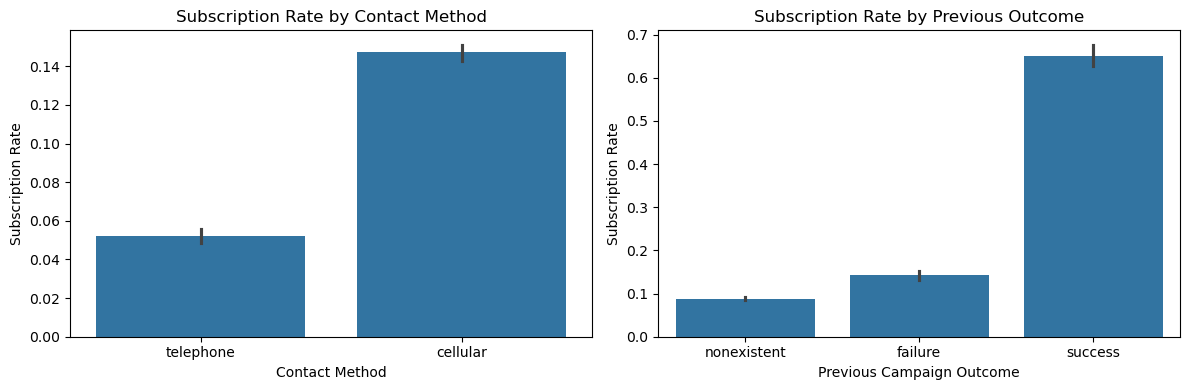

In [7]:
# Plot subscription rates by contact method and prior outcome.
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
sns.barplot(data = df, x = 'contact', y = 'subscribed', estimator = 'mean', ax = ax[0])
ax[0].set_title('Subscription Rate by Contact Method')
ax[0].set_xlabel('Contact Method')
ax[0].set_ylabel('Subscription Rate')

sns.barplot(data = df, x = 'poutcome', y = 'subscribed', estimator = 'mean', ax = ax[1])
ax[1].set_title('Subscription Rate by Previous Outcome')
ax[1].set_xlabel('Previous Campaign Outcome')
ax[1].set_ylabel('Subscription Rate')
plt.tight_layout()

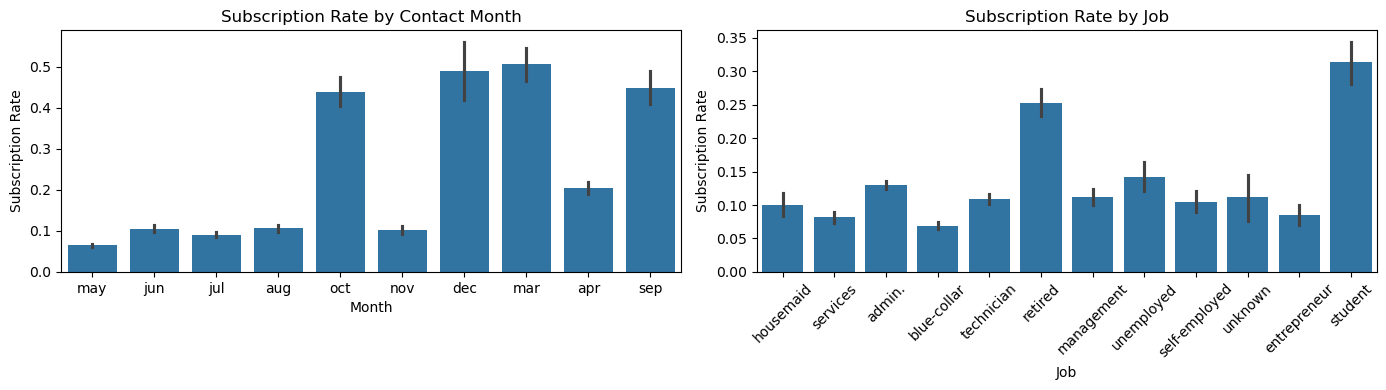

In [8]:
# Plot subscription rates by month and job.
fig, ax = plt.subplots(1, 2, figsize = (14, 4))
sns.barplot(data = df, x = 'month', y = 'subscribed', estimator = 'mean', ax = ax[0])
ax[0].set_title('Subscription Rate by Contact Month')
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Subscription Rate')

sns.barplot(data = df, x = 'job', y = 'subscribed', estimator = 'mean', ax = ax[1])
ax[1].set_title('Subscription Rate by Job')
ax[1].set_xlabel('Job')
ax[1].set_ylabel('Subscription Rate')
ax[1].tick_params(axis = 'x', rotation = 45)
plt.tight_layout()

**Observation:** The data includes 41,188 clients and 22 columns. It has enough records to compare several models.

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



There are no true missing values. Some categorical columns use `unknown` as a missing-value code, and no type coercion is needed.


**Observation:** The data is complete, but `unknown` is still useful information. It should remain as a category.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [9]:
# Display the data types and non-null values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

The business objective is to predict whether a client will subscribe to a term deposit so the bank can focus marketing efforts on likely customers.


In [10]:
# Count missing values in each column.
df.isna().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
subscribed        0
dtype: int64

**Observation:** The goal is to identify clients who may subscribe. This can help focus marketing calls.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [11]:
# Drop duration because it is only known after the call.
X = pd.get_dummies(df.drop(['y', 'subscribed', 'duration'], axis = 1), drop_first = True)
y = df['subscribed']


In [12]:
# Display the first five rows of the feature matrix.
X.head()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False


In [13]:
# Display the shapes of the features and target.
X.shape, y.shape


((41188, 52), (41188,))

**Observation:** The model uses information available before the call. `duration` was removed because it would leak information from the call.

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [14]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)


In [15]:
# Display the shapes of the training and testing sets.
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((30891, 52), (10297, 52), (30891,), (10297,))

In [16]:
# Display the class balance in the training data.
y_train.value_counts(normalize = True)


subscribed
0    0.887346
1    0.112654
Name: proportion, dtype: float64

**Observation:** The split keeps the class balance in both sets. This makes the test comparison more reliable.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [17]:
# Calculate the majority-class baseline accuracy.
baseline = y_train.value_counts(normalize = True).max()
baseline


np.float64(0.8873458288821987)

The baseline is the majority-class accuracy.


**Observation:** The baseline is about 88.7%. A useful model needs to score above this level.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [18]:
# Scale features before fitting models that depend on distance or magnitude.
logreg = Pipeline([('scaler', StandardScaler()),
                   ('logreg', LogisticRegression(max_iter = 1000, random_state = 42))])
logreg.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

### Problem 9: Score the Model

What is the accuracy of your model?

In [19]:
# Score Logistic Regression on the test data.
logreg.score(X_test, y_test)


0.9015247159366806

Accuracy gives the overall share of correct predictions and provides a direct comparison with the majority-class baseline. ROC AUC shows how well each model separates subscribers from non-subscribers. Precision and recall show how often the model finds subscribers and how often those predictions are correct.


**Observation:** Logistic Regression reaches about 90.2% accuracy. It improves on the baseline.

In [20]:
# Coefficients show the direction and relative strength of each feature.
coef_df = pd.DataFrame({'Feature': X.columns,
                        'Coefficient': logreg.named_steps['logreg'].coef_[0]})
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by = 'Absolute Coefficient', ascending = False).head()

,Feature,Coefficient,Absolute Coefficient
4,emp.var.rate,-2.218487,2.218487
5,cons.price.idx,1.126854,1.126854
7,euribor3m,0.423915,0.423915
8,nr.employed,0.374198,0.374198
36,contact_telephone,-0.338464,0.338464


**Observation:** The largest coefficients are economic indicators. They move together, so they should be read as one group. Contact method is the strongest client-level signal.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [21]:
# Scale Logistic Regression, KNN, and SVM for a fair comparison.
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                     ('logreg', LogisticRegression(max_iter = 1000, random_state = 42))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    'Decision Tree': DecisionTreeClassifier(random_state = 42),
    'SVM': Pipeline([('scaler', StandardScaler()), ('svc', SVC())])
}

results = []

# Record fit time and accuracy for each model.
for name, model in models.items():
    start = time()
    model.fit(X_train, y_train)
    fit_time = time() - start
    cv_accuracy = cross_val_score(model, X_train, y_train, cv = 3).mean()
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
    results.append({'Model': name,
                    'Train Time': fit_time,
                    'CV Accuracy': cv_accuracy,
                    'Train Accuracy': model.score(X_train, y_train),
                    'Test Accuracy': model.score(X_test, y_test),
                    'ROC AUC': roc_auc_score(y_test, scores)})


In [22]:
# Create a table of model results.
results_df = pd.DataFrame(results)


In [23]:
# Sort models by test accuracy.
results_df.sort_values(by = 'Test Accuracy', ascending = False)


,Model,Train Time,CV Accuracy,Train Accuracy,Test Accuracy,ROC AUC
0,Logistic Regression,0.149583,0.899291,0.899647,0.901525,0.805145
3,SVM,45.452297,0.896960,0.909585,0.900651,0.721112
1,KNN,0.053906,0.887281,0.911560,0.895698,0.730069
2,Decision Tree,0.192813,0.836587,0.995856,0.843450,0.625781


,precision,recall,f1-score,support
0,0.908972,0.987961,0.946822,9137.000000
1,0.699454,0.220690,0.335518,1160.000000
accuracy,0.901525,0.901525,0.901525,0.901525
macro avg,0.804213,0.604325,0.641170,10297.000000
weighted avg,0.885369,0.901525,0.877956,10297.000000


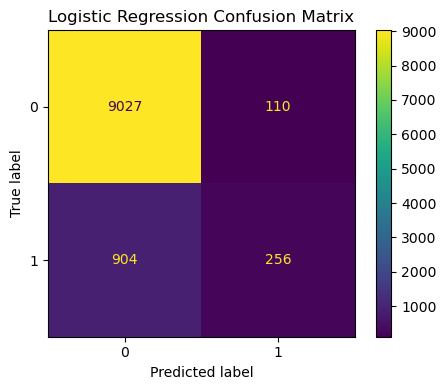

In [24]:
# Show the Logistic Regression confusion matrix and classification report.
fig, ax = plt.subplots(figsize = (5, 4))
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, ax = ax)
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()

report_df = pd.DataFrame(classification_report(y_test, logreg.predict(X_test), output_dict = True)).transpose()
report_df

**Observation:** Logistic Regression has the best test accuracy. The unpruned Decision Tree overfits, and SVM takes much longer to fit.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [25]:
# Use three folds to keep cross-validation practical while comparing with SVM.
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_grid = {'knn__n_neighbors': [3, 5, 7, 9]}
knn_search = GridSearchCV(knn_pipe, knn_grid, scoring = 'roc_auc', cv = 3)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
start = time()
best_knn.fit(X_train, y_train)
best_knn_fit_time = time() - start
knn_search.best_params_


{'knn__n_neighbors': 9}

In [26]:
# Tune tree depth and leaf size using the same three-fold ROC AUC score.
dtree_grid = {'max_depth': [3, 5, 7, 10, None],
              'min_samples_leaf': [1, 10, 50]}
dtree_search = GridSearchCV(DecisionTreeClassifier(random_state = 42),
                            dtree_grid, scoring = 'roc_auc', cv = 3)
dtree_search.fit(X_train, y_train)
best_dtree = dtree_search.best_estimator_
start = time()
best_dtree.fit(X_train, y_train)
best_dtree_fit_time = time() - start
dtree_search.best_params_

{'max_depth': 7, 'min_samples_leaf': 10}

In [27]:
# Add the tuned model results to the comparison table.
tuned_results = pd.DataFrame([{'Model': 'Tuned KNN',
                                 'Train Time': best_knn_fit_time,
                                 'CV Accuracy': cross_val_score(best_knn, X_train, y_train, cv = 3).mean(),
                                 'Train Accuracy': best_knn.score(X_train, y_train),
                                 'Test Accuracy': best_knn.score(X_test, y_test),
                                 'ROC AUC': roc_auc_score(y_test, best_knn.predict_proba(X_test)[:, 1])},
                                {'Model': 'Tuned Decision Tree',
                                 'Train Time': best_dtree_fit_time,
                                 'CV Accuracy': cross_val_score(best_dtree, X_train, y_train, cv = 3).mean(),
                                 'Train Accuracy': best_dtree.score(X_train, y_train),
                                 'Test Accuracy': best_dtree.score(X_test, y_test),
                                 'ROC AUC': roc_auc_score(y_test, best_dtree.predict_proba(X_test)[:, 1])}])
results_df = pd.concat([results_df, tuned_results], ignore_index = True)
results_df.sort_values(by = 'ROC AUC', ascending = False)


,Model,Train Time,CV Accuracy,Train Accuracy,Test Accuracy,ROC AUC
5,Tuned Decision Tree,0.060282,0.899194,0.906898,0.898903,0.806068
0,Logistic Regression,0.149583,0.899291,0.899647,0.901525,0.805145
4,Tuned KNN,0.066798,0.891781,0.904859,0.898126,0.755175
1,KNN,0.053906,0.887281,0.911560,0.895698,0.730069
3,SVM,45.452297,0.896960,0.909585,0.900651,0.721112
2,Decision Tree,0.192813,0.836587,0.995856,0.843450,0.625781


**Observation:** The tuned Decision Tree and Logistic Regression have nearly the same ROC AUC. Logistic Regression is the better default because it is fast and easier to explain.

### Findings and Next Steps

The bank wants to identify clients worth calling about a term deposit before the call happens. We tested four models on 41,188 past contacts. Call duration was excluded because it is only known after the call.

Logistic Regression and the tuned Decision Tree are effectively tied. Their ROC AUC values differ by less than 0.001. Logistic Regression had the best test accuracy and trained much faster than SVM. The unpruned Decision Tree overfit because it was almost perfect on training data but weak on new data.

Accuracy alone is not enough because most clients do not subscribe. The best model reached 90.2% accuracy, only 1.4 points above the 88.7% majority-class baseline. Of the 366 clients flagged as likely subscribers, 256 subscribed. This is a success rate near 70%, compared with 11% if the bank called everyone. The model missed 904 subscribers, so it should rank the call list rather than decide who never gets called.

Use Logistic Regression to score and rank the call list. It ties the tuned Decision Tree on performance, trains quickly, and is easier to explain. Prioritize cellular contacts and prior subscribers. Set the score cutoff based on the cost of a call and the value of a subscription. Retrain the model as economic conditions change.